In [36]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [37]:
import csv
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from joblib import load
from PIL import Image
import json, pickle
import gc
from joblib import Parallel, delayed
from copy import deepcopy


sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *
from macaw.generators import library_evolver

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600
from matplotlib.ticker import AutoMinorLocator
from scipy.stats import gaussian_kde


from copy import deepcopy
from joblib import Parallel, delayed
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%run "./plotting.py"

1.0.1


In [38]:
from art.core import RecommendationEngine
import art.utility as utils
from art.plot import predictions_vs_observations, predictions_distr_vs_observations
import pickle
import cloudpickle

In [39]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
HuggingFaceModelsDir = os.path.join(dataDir, 'HuggingFace_models/')
DORANETmoleculesDataDir = '/users/sghosh6/DTRA_project/MACAW/doranet/scripts'
resultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW_allDB_generative/')
os.makedirs(resultsDir, exist_ok=True)

### Load saved `MACAW` transformer

In [40]:
macaw_load_path = os.path.join(resultsDir, "combinedEbolaVirusData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

MACAW transformer loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/combinedEbolaVirusData_allDB_MACAW_transformer.joblib


### Load pre-trained `ART` model

ART model loaded from: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative/ART_MACAW/ART_results/art.cpkl
ART output directory: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB_generative


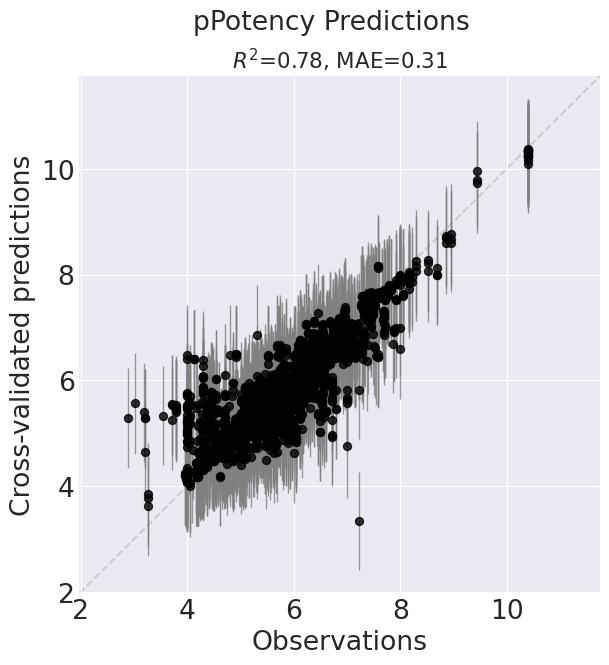

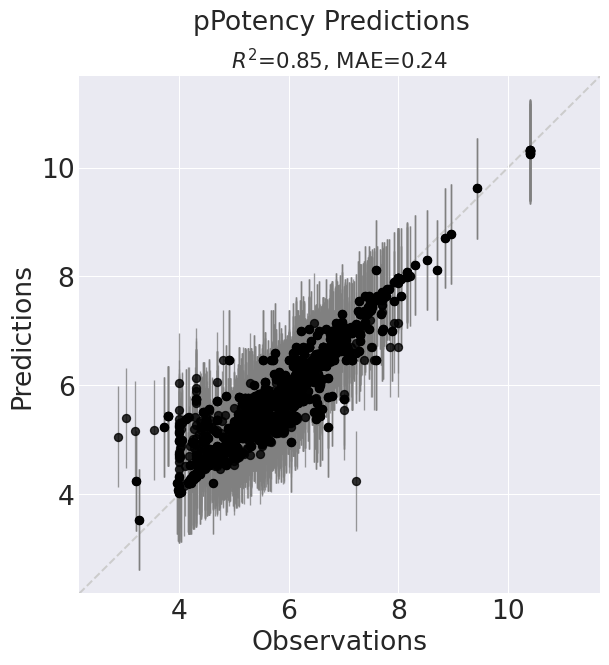

In [41]:
ARTtrainedModelFile = os.path.join(resultsDir, "ART_MACAW/ART_results/art.cpkl")
with open(ARTtrainedModelFile, "rb") as f:
    art_macaw = cloudpickle.load(f)

print(f"ART model loaded from: {ARTtrainedModelFile}")

# Force ART to use the current result directory
art_macaw.output_dir = resultsDir
os.makedirs(art_macaw.output_dir, exist_ok=True)

print(f"ART output directory: {art_macaw.output_dir}")

# Generate both ART plots
predictions_vs_observations(art_macaw,cv=True,error_bars=True)

predictions_vs_observations(art_macaw,cv=False,error_bars=True)

## Load compounds with `predicted` and `experimental` potency

### `DORAnet` generated molecules with starter: `Inosine + Adenosine + Guanosine + Xanthosine`

In [42]:
combinedEbola_allDORAnetGenerated_Antivirals_wART = pd.read_csv(resultsDir + "/combinedEbola_allDORAnetGenerated_Antivirals_ARTprediction.csv")
combinedEbola_allDORAnetGenerated_Antivirals_wART = combinedEbola_allDORAnetGenerated_Antivirals_wART[['Canonical_SMILES', 'source_DataBase','pPotency_prediction','pPotency_std']]
combinedEbola_allDORAnetGenerated_Antivirals_wART

,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,InosineOnly_gen3,6.156156,0.476241
1,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,InosineOnly_gen3,5.989034,0.473052
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,InosineOnly_gen3,5.906960,0.473610
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,InosineOnly_gen3,5.825261,0.472941
4,CC(=O)OP(=O)(O)OC(C)=O,AdenosineOnly_gen3,5.757650,0.479591
...,...,...,...,...
20367,CC(O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@]1(C#N)n1cn...,AdenosineOnly_gen3,5.036312,0.479170
20368,N#C[C@]1(n2cnc3c(=O)[nH]c(N)nc32)O[C@H](CO)[C@...,GuanosineOnly_gen3,4.995117,0.477091
20369,N#C[C@]1(n2cnc3c(=O)[nH]cnc32)O[C@H](CO)[C@@H]...,InosineOnly_gen3,4.944989,0.477190
20370,N#C[C@]1(n2cnc3c(N)ncnc32)O[C@H](C(O)O)[C@@H](...,AdenosineOnly_gen3,4.925072,0.478121


### `DORAnet` generated molecules with starter: `Remdesivir`

In [43]:
RemdesivirOnly_DORAnetGenerated_wART = pd.read_csv(resultsDir + "/RemdesivirOnly_DORAnetGenerated_ARTprediction.csv")
RemdesivirOnly_DORAnetGenerated_wART = RemdesivirOnly_DORAnetGenerated_wART[['Canonical_SMILES', 'source_DataBase','pPotency_prediction','pPotency_std']]
RemdesivirOnly_DORAnetGenerated_wART

,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std
0,C[C@H](N[P@](=O)(OC[C@H]1O[C@@](C#N)(c2ccc3c(N...,RemdesivirOnly_gen2,6.829773,0.470426
1,CCC(CC)COC(=O)C(C)N[P@](=O)(OC[C@H]1O[C@@](C#N...,RemdesivirOnly_gen2,6.628576,0.469760
2,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,RemdesivirOnly_gen2,6.628576,0.469760
3,CCCC(O)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](...,RemdesivirOnly_gen2,6.535413,0.475037
4,CC(C)CCOC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](...,RemdesivirOnly_gen2,6.531831,0.474625
...,...,...,...,...
40197,N#C[C@@]1(c2ccc3c(N)ncnn23)O[C@]2(CO)O[C@@H]1[...,RemdesivirOnly_gen2,5.013693,0.477513
40198,CC[C@]1(O)[C@H](O)[C@@H](CO)O[C@@]1(C#N)c1ccc2...,RemdesivirOnly_gen2,4.938740,0.478270
40199,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,RemdesivirOnly_gen2,4.823478,0.471504
40200,CCC(CC)COC(=O)C(C)N[P@](=O)(OC[C@H]1O[C@@](C#N...,RemdesivirOnly_gen2,4.823478,0.471504


### Combine the data frames

In [45]:
# List the dataframes in the order you want them joined
dFs_to_combine = [
    combinedEbola_allDORAnetGenerated_Antivirals_wART, 
    RemdesivirOnly_DORAnetGenerated_wART, 
]

# Concatenate vertically
starterCandidates_4MACAW_generation = pd.concat(dFs_to_combine, axis=0, ignore_index=True)
starterCandidates_4MACAW_generation

,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std
0,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,InosineOnly_gen3,6.156156,0.476241
1,CC(C)(COP(=O)(O)OP(=O)(O)OC[C@H]1O[C@@H](n2cnc...,InosineOnly_gen3,5.989034,0.473052
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,InosineOnly_gen3,5.906960,0.473610
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,InosineOnly_gen3,5.825261,0.472941
4,CC(=O)OP(=O)(O)OC(C)=O,AdenosineOnly_gen3,5.757650,0.479591
...,...,...,...,...
60569,N#C[C@@]1(c2ccc3c(N)ncnn23)O[C@]2(CO)O[C@@H]1[...,RemdesivirOnly_gen2,5.013693,0.477513
60570,CC[C@]1(O)[C@H](O)[C@@H](CO)O[C@@]1(C#N)c1ccc2...,RemdesivirOnly_gen2,4.938740,0.478270
60571,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,RemdesivirOnly_gen2,4.823478,0.471504
60572,CCC(CC)COC(=O)C(C)N[P@](=O)(OC[C@H]1O[C@@](C#N...,RemdesivirOnly_gen2,4.823478,0.471504


## Use MACAW's `library_evolver` to generate new molecules

In [46]:
# ============================================================
# Concise MACAW + ART multi-campaign generation
# Seeds: highest pPotency_prediction compounds
# Goal: generated molecules close to targetPotency
# ============================================================


# -----------------------------
# User settings
# -----------------------------
targetPotency = 7.5
smilesCol = "Canonical_SMILES"
potencyCol = "pPotency_prediction"
stdCol = "pPotency_std"
sourceCol = "source_DataBase"

nTargetClosestSeeds = 300
randomSeeds = [42, 52, 62, 72, 82]
outputPrefix = "MACAW_generatedCompound"
saveOutputs = True


# -----------------------------
# Helper: canonicalize SMILES
# -----------------------------
def canonicalizeSmiles(smiles):
    """Return canonical SMILES or None if invalid."""
    if pd.isna(smiles):
        return None

    mol = Chem.MolFromSmiles(str(smiles).strip())
    return Chem.MolToSmiles(mol, canonical=True) if mol is not None else None


# -----------------------------
# Helper: ART mean prediction wrapper for library_evolver
# -----------------------------
def artMeanModelForLibraryEvolver(X):
    """
    MACAW library_evolver passes MACAW embeddings X into this function.
    This wrapper converts X into MACAW_ feature columns and returns only
    ART mean pPotency predictions.
    """
    macawFeatureDF = pd.DataFrame(
        X,
        columns=[f"MACAW_{i}" for i in range(X.shape[1])]
    )

    pred = art_macaw.predict(macawFeatureDF)

    if isinstance(pred, pd.DataFrame):
        for col in ["pPotency_prediction", "prediction", "mean"]:
            if col in pred.columns:
                return pred[col].to_numpy()

    if isinstance(pred, dict):
        for key in ["pPotency_prediction", "prediction", "mean", "y_mean"]:
            if key in pred:
                return np.asarray(pred[key]).ravel()

    if isinstance(pred, (tuple, list)):
        return np.asarray(pred[0]).ravel()

    return np.asarray(pred).ravel()


# -----------------------------
# Step 1: choose starting seeds closest to targetPotency
# -----------------------------
seedDF = starterCandidates_4MACAW_generation.copy()

# Clean and canonicalize SMILES
seedDF[smilesCol] = seedDF[smilesCol].apply(canonicalizeSmiles)

# Convert potency to numeric safely
seedDF[potencyCol] = pd.to_numeric(seedDF[potencyCol], errors="coerce")

# Keep valid rows only
seedDF = seedDF.dropna(subset=[smilesCol, potencyCol]).copy()

# Important: sort BEFORE dedup so the best row is kept for duplicate SMILES
seedDF["seedTargetError"] = (seedDF[potencyCol] - targetPotency).abs()

seedDF = (
    seedDF
    .sort_values("seedTargetError", ascending=True)
    .drop_duplicates(subset=[smilesCol], keep="first")
    .reset_index(drop=True)
)

# Select molecules closest to targetPotency
seedDF = seedDF.nsmallest(nTargetClosestSeeds, "seedTargetError").reset_index(drop=True)

seedDF["seedSelectionScore"] = seedDF["seedTargetError"]
seedDF["seedRank"] = np.arange(1, len(seedDF) + 1)

seedSmiles = seedDF[smilesCol].tolist()

print(f"targetPotency used now: {targetPotency}")
print(f"Number of cleaned seed molecules: {len(seedSmiles)}")

display(
    seedDF[
        [
            "seedRank",
            smilesCol,
            sourceCol,
            potencyCol,
            stdCol,
            "seedTargetError",
            "seedSelectionScore",
        ]
    ].head(20)
)

# -----------------------------
# Step 2: define compact multi-campaign settings
# -----------------------------
campaignConfigs = [
    {
        "campaignLabel": "transition_empirical_refine",
        "algorithm": "transition",
        "p": "empirical",
        "k1": 8000,
        "k2": 200,
        "n_rounds": 5,
        "n_hits": 100,
        "noise_factor": [0.30, 0.22, 0.16, 0.10, 0.08],
    },
    {
        "campaignLabel": "transition_cumsum_broad",
        "algorithm": "transition",
        "p": "cumsum",
        "k1": 15000,
        "k2": 400,
        "n_rounds": 6,
        "n_hits": 150,
        "noise_factor": [0.65, 0.50, 0.35, 0.25, 0.16, 0.10],
    },
    {
        "campaignLabel": "position_exp_broad",
        "algorithm": "position",
        "p": "exp",
        "k1": 15000,
        "k2": 400,
        "n_rounds": 6,
        "n_hits": 150,
        "noise_factor": [0.70, 0.55, 0.40, 0.28, 0.18, 0.10],
    },
    {
        "campaignLabel": "dual_cumsum_broad",
        "algorithm": "dual",
        "p": "cumsum",
        "k1": 12000,
        "k2": 300,
        "n_rounds": 6,
        "n_hits": 150,
        "noise_factor": [0.60, 0.45, 0.32, 0.22, 0.15, 0.10],
    },
]


# -----------------------------
# Step 3: run multi-campaign library_evolver
# -----------------------------
allResults = []
failedCampaigns = []

for cfg in campaignConfigs:
    for seed in randomSeeds:
        campaignLabel = f"{cfg['campaignLabel']}_seed{seed}"
        print(f"\nRunning {campaignLabel}")

        try:
            result = library_evolver(
                smiles=seedSmiles,
                model=artMeanModelForLibraryEvolver,
                mcw=mcw,
                spec=targetPotency,
                k1=cfg["k1"],
                k2=cfg["k2"],
                n_rounds=cfg["n_rounds"],
                n_hits=cfg["n_hits"],
                noise_factor=cfg["noise_factor"],
                algorithm=cfg["algorithm"],
                p=cfg["p"],
                force_new=True,
                random_state=seed,
            )

            # Handle MACAW versions returning either SMILES only or (SMILES, predictions)
            if isinstance(result, tuple) and len(result) >= 2:
                smilesOut, predOut = result[0], result[1]
            else:
                smilesOut = result
                predOut = artMeanModelForLibraryEvolver(mcw.transform(smilesOut))

            campaignDF = pd.DataFrame({
                smilesCol: smilesOut,
                potencyCol: np.asarray(predOut).ravel(),
                "target_pPotency": targetPotency,
                "campaignLabel": campaignLabel,
                "campaignBase": cfg["campaignLabel"],
                "randomSeed": seed,
                "algorithm": cfg["algorithm"],
                "p": cfg["p"],
                "k1": cfg["k1"],
                "k2": cfg["k2"],
                "n_rounds": cfg["n_rounds"],
            })

            campaignDF[smilesCol] = campaignDF[smilesCol].apply(canonicalizeSmiles)
            campaignDF = campaignDF.dropna(subset=[smilesCol])
            campaignDF["targetError"] = (campaignDF[potencyCol] - targetPotency).abs()

            allResults.append(campaignDF)

            print(
                f"Finished {campaignLabel}: "
                f"{len(campaignDF)} molecules, "
                f"best targetError = {campaignDF['targetError'].min():.4f}"
            )

        except Exception as exc:
            failedCampaigns.append({
                "campaignLabel": campaignLabel,
                "errorMessage": str(exc),
            })
            print(f"FAILED {campaignLabel}: {exc}")


# -----------------------------
# Step 4: merge, deduplicate, rank, summarize, save
# -----------------------------
if len(allResults) == 0:
    expandedTargetMatchedDF = pd.DataFrame()
    campaignSummaryDF = pd.DataFrame()
    failedCampaignDF = pd.DataFrame(failedCampaigns)
    print("\nNo successful campaigns.")
else:
    expandedTargetMatchedDF = pd.concat(allResults, ignore_index=True)

    # Deduplicate and keep molecule closest to targetPotency
    expandedTargetMatchedDF = (
        expandedTargetMatchedDF
        .sort_values("targetError", ascending=True)
        .drop_duplicates(subset=[smilesCol], keep="first")
        .reset_index(drop=True)
    )

    expandedTargetMatchedDF["targetMatchRank"] = np.arange(
        1, len(expandedTargetMatchedDF) + 1
    )

    expandedTargetMatchedDF["within_0p10"] = expandedTargetMatchedDF["targetError"] <= 0.10
    expandedTargetMatchedDF["within_0p25"] = expandedTargetMatchedDF["targetError"] <= 0.25
    expandedTargetMatchedDF["within_0p50"] = expandedTargetMatchedDF["targetError"] <= 0.50

    campaignSummaryDF = (
        expandedTargetMatchedDF
        .groupby("campaignBase")
        .agg(
            nUniqueReturned=(smilesCol, "count"),
            bestTargetError=("targetError", "min"),
            medianTargetError=("targetError", "median"),
            nWithin0p25=("within_0p25", "sum"),
            nWithin0p50=("within_0p50", "sum"),
        )
        .reset_index()
        .sort_values(["bestTargetError", "nWithin0p25"], ascending=[True, False])
    )

    failedCampaignDF = pd.DataFrame(failedCampaigns)

    print("\nMULTI-CAMPAIGN SEARCH COMPLETE")
    print(f"Total unique generated molecules: {len(expandedTargetMatchedDF)}")
    print(f"Molecules within ±0.25 pPotency: {expandedTargetMatchedDF['within_0p25'].sum()}")

    display(
        expandedTargetMatchedDF[
            [
                "targetMatchRank",
                smilesCol,
                potencyCol,
                "target_pPotency",
                "targetError",
                "campaignLabel",
                "algorithm",
                "p",
            ]
        ].head(50)
    )

    display(campaignSummaryDF)

    if saveOutputs:
        seedDF.to_csv(resultsDir + f"{outputPrefix}_highestPotency_seed_molecules.csv", index=False)
        expandedTargetMatchedDF.to_csv(resultsDir + f"{outputPrefix}_multiCampaign_all_results.csv", index=False)
        campaignSummaryDF.to_csv(resultsDir + f"{outputPrefix}_multiCampaign_summary.csv", index=False)
        expandedTargetMatchedDF.head(500).to_csv(resultsDir + f"{outputPrefix}_multiCampaign_top500.csv", index=False)
        expandedTargetMatchedDF[expandedTargetMatchedDF["within_0p25"]].to_csv(resultsDir + f"{outputPrefix}_multiCampaign_within_0p25.csv",index=False,)

        if len(failedCampaignDF) > 0:
            failedCampaignDF.to_csv(f"{outputPrefix}_failed_campaigns.csv", index=False)

        print("\nSaved outputs:")
        print(f"  {outputPrefix}_highestPotency_seed_molecules.csv")
        print(f"  {outputPrefix}_multiCampaign_all_results.csv")
        print(f"  {outputPrefix}_multiCampaign_summary.csv")
        print(f"  {outputPrefix}_multiCampaign_top500.csv")
        print(f"  {outputPrefix}_multiCampaign_within_0p25.csv")

targetPotency used now: 7.5
Number of cleaned seed molecules: 300


,seedRank,Canonical_SMILES,source_DataBase,pPotency_prediction,pPotency_std,seedTargetError,seedSelectionScore
0,1,C[C@H](N[P@](=O)(OC[C@H]1O[C@@](C#N)(c2ccc3c(N...,RemdesivirOnly_gen2,6.829773,0.470426,0.670227,0.670227
1,2,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,RemdesivirOnly_gen2,6.628576,0.469760,0.871424,0.871424
2,3,CCC(CC)COC(=O)C(C)N[P@](=O)(OC[C@H]1O[C@@](C#N...,RemdesivirOnly_gen2,6.628576,0.469760,0.871424,0.871424
3,4,CCCC(O)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](...,RemdesivirOnly_gen2,6.535413,0.475037,0.964587,0.964587
4,5,CC(C)CCOC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](...,RemdesivirOnly_gen2,6.531831,0.474625,0.968169,0.968169
5,6,CCCC(CC)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,RemdesivirOnly_gen2,6.530264,0.475025,0.969736,0.969736
6,7,CCCCOC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#N...,RemdesivirOnly_gen2,6.528331,0.475184,0.971669,0.971669
7,8,CCC(CC)OC(=O)C(C)(C)N[P@](=O)(OC[C@H]1O[C@@](C...,RemdesivirOnly_gen2,6.527181,0.475037,0.972819,0.972819
8,9,CCCOC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](C#N)...,RemdesivirOnly_gen2,6.526691,0.476561,0.973309,0.973309
9,10,CCC(CC(C)C)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C...,RemdesivirOnly_gen2,6.523146,0.474642,0.976854,0.976854



Running transition_empirical_refine_seed42

Round 1
max_len set to 109.
5368 unique molecules generated.
max_len set to 110.

Round 2
5721 unique molecules generated.
max_len set to 110.

Round 3
5733 unique molecules generated.
max_len set to 110.

Round 4
5792 unique molecules generated.
max_len set to 110.

Round 5
5799 unique molecules generated.
Finished transition_empirical_refine_seed42: 100 molecules, best targetError = 1.2722

Running transition_empirical_refine_seed52

Round 1
max_len set to 109.
5515 unique molecules generated.
max_len set to 110.

Round 2
5697 unique molecules generated.
max_len set to 110.

Round 3
5655 unique molecules generated.
max_len set to 110.

Round 4
5851 unique molecules generated.
max_len set to 110.

Round 5
5846 unique molecules generated.
Finished transition_empirical_refine_seed52: 100 molecules, best targetError = 1.1907

Running transition_empirical_refine_seed62

Round 1
max_len set to 109.
5477 unique molecules generated.
max_len set to

,targetMatchRank,Canonical_SMILES,pPotency_prediction,target_pPotency,targetError,campaignLabel,algorithm,p
0,1,CCC1CCC2(ON[O-])NC(C)NCOC3CCC45C6C(C=CC=C([PH]...,6.514252,7.5,0.985748,position_exp_broad_seed42,position,exp
1,2,CC=CC=COOC1CCC2=CP(C)(=O)C2NC(O)CCPC2=CC=C1OC1...,6.459090,7.5,1.040910,dual_cumsum_broad_seed52,dual,cumsum
2,3,COCCC1CCON2C3CCCCCCC=CCC4CC(P)OCCCCNC(C)CCC=CS...,6.458808,7.5,1.041192,position_exp_broad_seed52,position,exp
3,4,C=P1(CO)NCOC2C=C1OCOC(CC)=CC(C)CCC=NC(O)C(O)C(...,6.455946,7.5,1.044054,dual_cumsum_broad_seed52,dual,cumsum
4,5,CCCNC(NCC1CC(CCPCN2CN2C=CON(O)C[PH](=O)S)=C(S)...,6.451856,7.5,1.048144,position_exp_broad_seed72,position,exp
5,6,CCC(CC)COC(C)CCC1COCC(C)C(=CC(C)[O-])C(C)(COC=...,6.446461,7.5,1.053539,dual_cumsum_broad_seed42,dual,cumsum
6,7,COCCCC1=CC(C)CNCC#CNC2CC1(C)OP=CON1C=[SH]CCC3(...,6.445950,7.5,1.054050,position_exp_broad_seed72,position,exp
7,8,CCC1=COC2C=C1CCC1(OPSO)CCC2(C)C=NCCC2(C)OC3C(=...,6.441242,7.5,1.058758,position_exp_broad_seed62,position,exp
8,9,CNCC1(O)C#CC=C(C=C(C)O)[SH]=CN=PCNS(C)=CCC2(C)...,6.438964,7.5,1.061036,position_exp_broad_seed82,position,exp
9,10,CC[PH](=O)NCCPOCC1(C2C(C(C)C)=CCC(N=PC(O)CC(=N...,6.436062,7.5,1.063938,transition_cumsum_broad_seed82,transition,cumsum


,campaignBase,nUniqueReturned,bestTargetError,medianTargetError,nWithin0p25,nWithin0p50
1,position_exp_broad,750,0.985748,1.283109,0,0
0,dual_cumsum_broad,750,1.040910,1.456993,0,0
2,transition_cumsum_broad,750,1.063938,1.342227,0,0
3,transition_empirical_refine,500,1.190651,1.648522,0,0



Saved outputs:
  MACAW_generatedCompound_highestPotency_seed_molecules.csv
  MACAW_generatedCompound_multiCampaign_all_results.csv
  MACAW_generatedCompound_multiCampaign_summary.csv
  MACAW_generatedCompound_multiCampaign_top500.csv
  MACAW_generatedCompound_multiCampaign_within_0p25.csv
